## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.

## Code-Struktur

Der gesamte Maschinenraum liegt im Paket [`tep/`](tep) und wird von allen
TEP-Notebooks geteilt. Dieses Notebook enthält nur noch, was es von
seinen Geschwistern unterscheidet: die Konfiguration und die Aufrufe.

| Modul | Inhalt |
|---|---|
| `tep/core.py` | Spaltennamen, Splits, Cutoffs, Vorverarbeitung, lineare Algebra — geteilt mit `tep.tsfresh` |
| `tep/plotting.py` | Confusion-Matrix-Darstellung, ebenfalls geteilt |
| `tep/eigen/config.py` | `SpectrumConfig` — alle Stellschrauben |
| `tep/eigen/data.py` | Trainings-CSVs lesen und zusammenführen |
| `tep/eigen/spectra.py` | Registry der Verfahren: `pca`, `dyca`, `dpca`, `cva`, `ica`, `lda` |
| `tep/eigen/aggregate.py` | Mittelwert/Std je Fehlerklasse, CSV-Export |
| `tep/eigen/plots.py` | die vier Standardplots |
| `tep/eigen/classify.py` | Klassifikation auf den exportierten Spektren |

Ein Verfahren ist ein `Spectrum` mit vier Angaben: Spaltenpräfix,
Klartextname, CSV-Stamm und die Rechnung selbst. Ein eigenes Verfahren
kommt über `tep.eigen.register(...)` dazu, ohne dass hier etwas
angefasst werden muss.

> Die Rechnungen sind zeilengetreu aus der früheren Notebook-Fassung
> übernommen — alle sechs Verfahren wurden vor dem Umbau als
> **bitidentisch** nachgewiesen, ebenso die Spaltennamen und die
> Export-Dateinamen. Die vorhandenen `*_eigenvalues_train*.csv` bleiben
> damit gültig.


In [1]:
# ============================================================
# Imports - der gemeinsame Unterbau steckt im Paket tep
# ============================================================
# Wird tep/**.py bearbeitet, muss der Kernel neu gestartet werden;
# alternativ die beiden autoreload-Zeilen aktivieren.
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pandas as pd

from tep.eigen import (SpectrumConfig, aggregate, export, fit_scaler,
                       load_train, merge_faults, run_spectra, versions)
from tep.eigen import plot_bars, plot_cv, plot_means, plot_stds

print(versions())

tsfresh 0.21.2 | pandas 3.0.3 | numpy 2.4.6 | sklearn 1.9.0 | Kerne: 8


In [2]:
# ============================================================
# Konfiguration - die EINZIGE Stelle, an der geschraubt wird
# ============================================================
# Alle nicht gesetzten Felder stehen auf den Defaults aus
# tep/eigen/config.py (pre_fault_cutoff=21, k_bar=10,
# plot_mode='linear', ...).
# runs_per_fault=3 kuerzt auf drei Laeufe je Fault - ein
# Probelauf von Minuten statt Stunden.

CFG = SpectrumConfig(
    method="dpca",
    scaling_mode="scaler",

    # Lags L -> 52*(L+1) = 156 Spalten im gestapelten Signal.
    dpca_lags=2,

    # Linienplots zeigen die ersten k_max Komponenten von 156.
    k_max=25,
)

## Rohdaten laden

Beide Trainings-CSVs werden **einmal** gelesen und zu einem DataFrame zusammengeführt. Der Pre-Fault-Bereich wird erst in der Spektren-Schleife verworfen (`CFG.pre_fault_cutoff = 21`): der Fehler wird 1 h nach Simulationsstart injiziert, bei 3-min-Sampling sind das 20 Samples Vorlauf. Ohne diesen Schnitt würden die ersten 20 Normalbetriebs-Samples die Fault-Statistik verwässern.

In [3]:
# ============================================================
# Rohdaten laden
# ============================================================
# Beide Trainings-CSVs muessen im Arbeitsverzeichnis liegen. Sie werden
# EINMAL gelesen und zu einem DataFrame (Fault 0..20) zusammengefuehrt;
# die Spektren-Schleife gruppiert daraus nach (fault, run).
df_ff, df_faulty = load_train(CFG)
df_all = merge_faults(df_ff, df_faulty)

# Scaler nur fitten, wenn er auch gebraucht wird (liest 250k Zeilen).
scaler = fit_scaler(CFG)

  lese TEP_FaultFree_Training.csv ...
  lese TEP_Faulty_Training.csv ...
  FaultFree_Training: (250000, 55)
  Faulty_Training   : (5000000, 55)
  Prozessvariablen  : 52
  kombiniert: (5250000, 55), Faults [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]
Fitte StandardScaler auf TEP_FaultFree_Training (Normalbetrieb) ...
  fertig.


## Spektrum je Lauf

Pro (faultNumber, simulationRun) eine Zerlegung. Das Ergebnis ist eine Zeile je Lauf mit den Werten als Spalten — genau die Form, die auch als CSV exportiert wird.

In [4]:
# ============================================================
# Spektrum je (Fault, Run)
# ============================================================
# Der teure Teil: eine Zerlegung pro Run. Runs, an denen das Verfahren
# numerisch scheitert oder die zu kurz sind, werden gezaehlt und
# uebersprungen - die Meldung darunter sagt wie viele.
per_run = run_spectra(CFG, df_all, scaler=scaler)

per_run.head()

Berechne DPCA-Spektrum pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

Erfolgreiche Runs: 10500


,faultNumber,simulationRun,dpca_1,dpca_2,dpca_3,dpca_4,dpca_5,dpca_6,dpca_7,dpca_8,...,dpca_147,dpca_148,dpca_149,dpca_150,dpca_151,dpca_152,dpca_153,dpca_154,dpca_155,dpca_156
0,0,1,0.112744,0.072396,0.037647,0.028705,0.026840,0.024711,0.023479,0.021881,...,0.000003,5.126608e-07,9.328253e-09,8.500057e-09,2.860952e-10,2.650272e-10,2.447678e-10,2.391569e-10,2.247776e-10,2.224193e-10
1,0,2,0.236600,0.155229,0.031886,0.027387,0.023449,0.018657,0.017303,0.016426,...,0.000002,2.965517e-07,6.296952e-09,5.977602e-09,2.097396e-10,1.938612e-10,1.867318e-10,1.746411e-10,1.588922e-10,1.329782e-10
2,0,3,0.222056,0.106775,0.035520,0.030598,0.028468,0.023686,0.019299,0.017405,...,0.000002,4.648207e-07,6.286205e-09,5.519426e-09,2.183003e-10,2.089101e-10,1.996346e-10,1.788487e-10,1.630713e-10,1.461145e-10
3,0,4,0.122552,0.098294,0.048365,0.036777,0.028153,0.025622,0.021667,0.020895,...,0.000003,3.378515e-07,8.991508e-09,7.632791e-09,2.670936e-10,2.419131e-10,2.157767e-10,2.037998e-10,1.896383e-10,1.755822e-10
4,0,5,0.173587,0.067002,0.031336,0.027889,0.025786,0.023148,0.021505,0.021159,...,0.000003,4.312601e-07,8.047494e-09,7.128929e-09,2.552459e-10,2.439681e-10,2.325433e-10,2.212318e-10,2.080448e-10,1.846929e-10


## Aggregation je Fehlerklasse

Über die 500 Läufe einer Fehlerklasse gemittelt, mit Standardabweichung. pandas rechnet mit `ddof=1` (Stichproben-Std), passend für N = 500.

In [5]:
# ============================================================
# Aggregation: Mittelwert und Standardabweichung je Fehlerklasse
# ============================================================
# Aus einer Zeile je (Fault, Run) wird eine Zeile je Fault mit
# <praefix>i_mean und <praefix>i_std.
agg = aggregate(CFG, per_run)

agg.head()

Aggregierte DPCA-Statistiken pro Fault: (21, 313)


d:\CCS\Forschung\tep\eigen\aggregate.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg = agg.reset_index()


,faultNumber,dpca_1_mean,dpca_1_std,dpca_2_mean,dpca_2_std,dpca_3_mean,dpca_3_std,dpca_4_mean,dpca_4_std,dpca_5_mean,...,dpca_152_mean,dpca_152_std,dpca_153_mean,dpca_153_std,dpca_154_mean,dpca_154_std,dpca_155_mean,dpca_155_std,dpca_156_mean,dpca_156_std
0,0,0.157233,0.040681,0.085921,0.024686,0.037922,0.003859,0.030861,0.003015,0.026399,...,2.370304e-10,2.470903e-11,2.198070e-10,2.295954e-11,2.032302e-10,2.089105e-11,1.881516e-10,2.008825e-11,1.683244e-10,2.006482e-11
1,1,0.413591,0.018485,0.276355,0.023643,0.138547,0.015867,0.045497,0.003702,0.023717,...,3.192812e-11,4.452879e-12,2.944423e-11,4.051591e-12,2.725519e-11,3.802364e-12,2.513701e-11,3.550438e-12,2.220198e-11,3.237596e-12
2,2,0.710056,0.009882,0.159364,0.004411,0.026632,0.005824,0.012928,0.003857,0.007990,...,2.729127e-11,1.612506e-12,2.518935e-11,1.482644e-12,2.330158e-11,1.396296e-12,2.144492e-11,1.374085e-12,1.910921e-11,1.561223e-12
3,3,0.161178,0.041440,0.088037,0.025289,0.038152,0.003952,0.030995,0.003090,0.026463,...,2.303305e-10,2.556841e-11,2.130735e-10,2.362279e-11,1.979059e-10,2.198665e-11,1.826177e-10,2.120000e-11,1.627702e-10,2.082920e-11
4,4,0.162046,0.041648,0.088668,0.025292,0.038999,0.004062,0.031383,0.003166,0.026733,...,2.316270e-10,2.590527e-11,2.133431e-10,2.333617e-11,1.977074e-10,2.159886e-11,1.826197e-10,2.030706e-11,1.626278e-10,2.013186e-11


## Visualisierung

Drei Blickwinkel auf dieselbe Aggregattabelle: das mittlere Niveau, seine Streuung über die Läufe und die dimensionslose relative Streuung. Dazu die ersten Komponenten als Balken mit der Fault-0-Referenz — dort ist am schnellsten zu sehen, welche Komponenten der Fehler wirklich verschiebt.

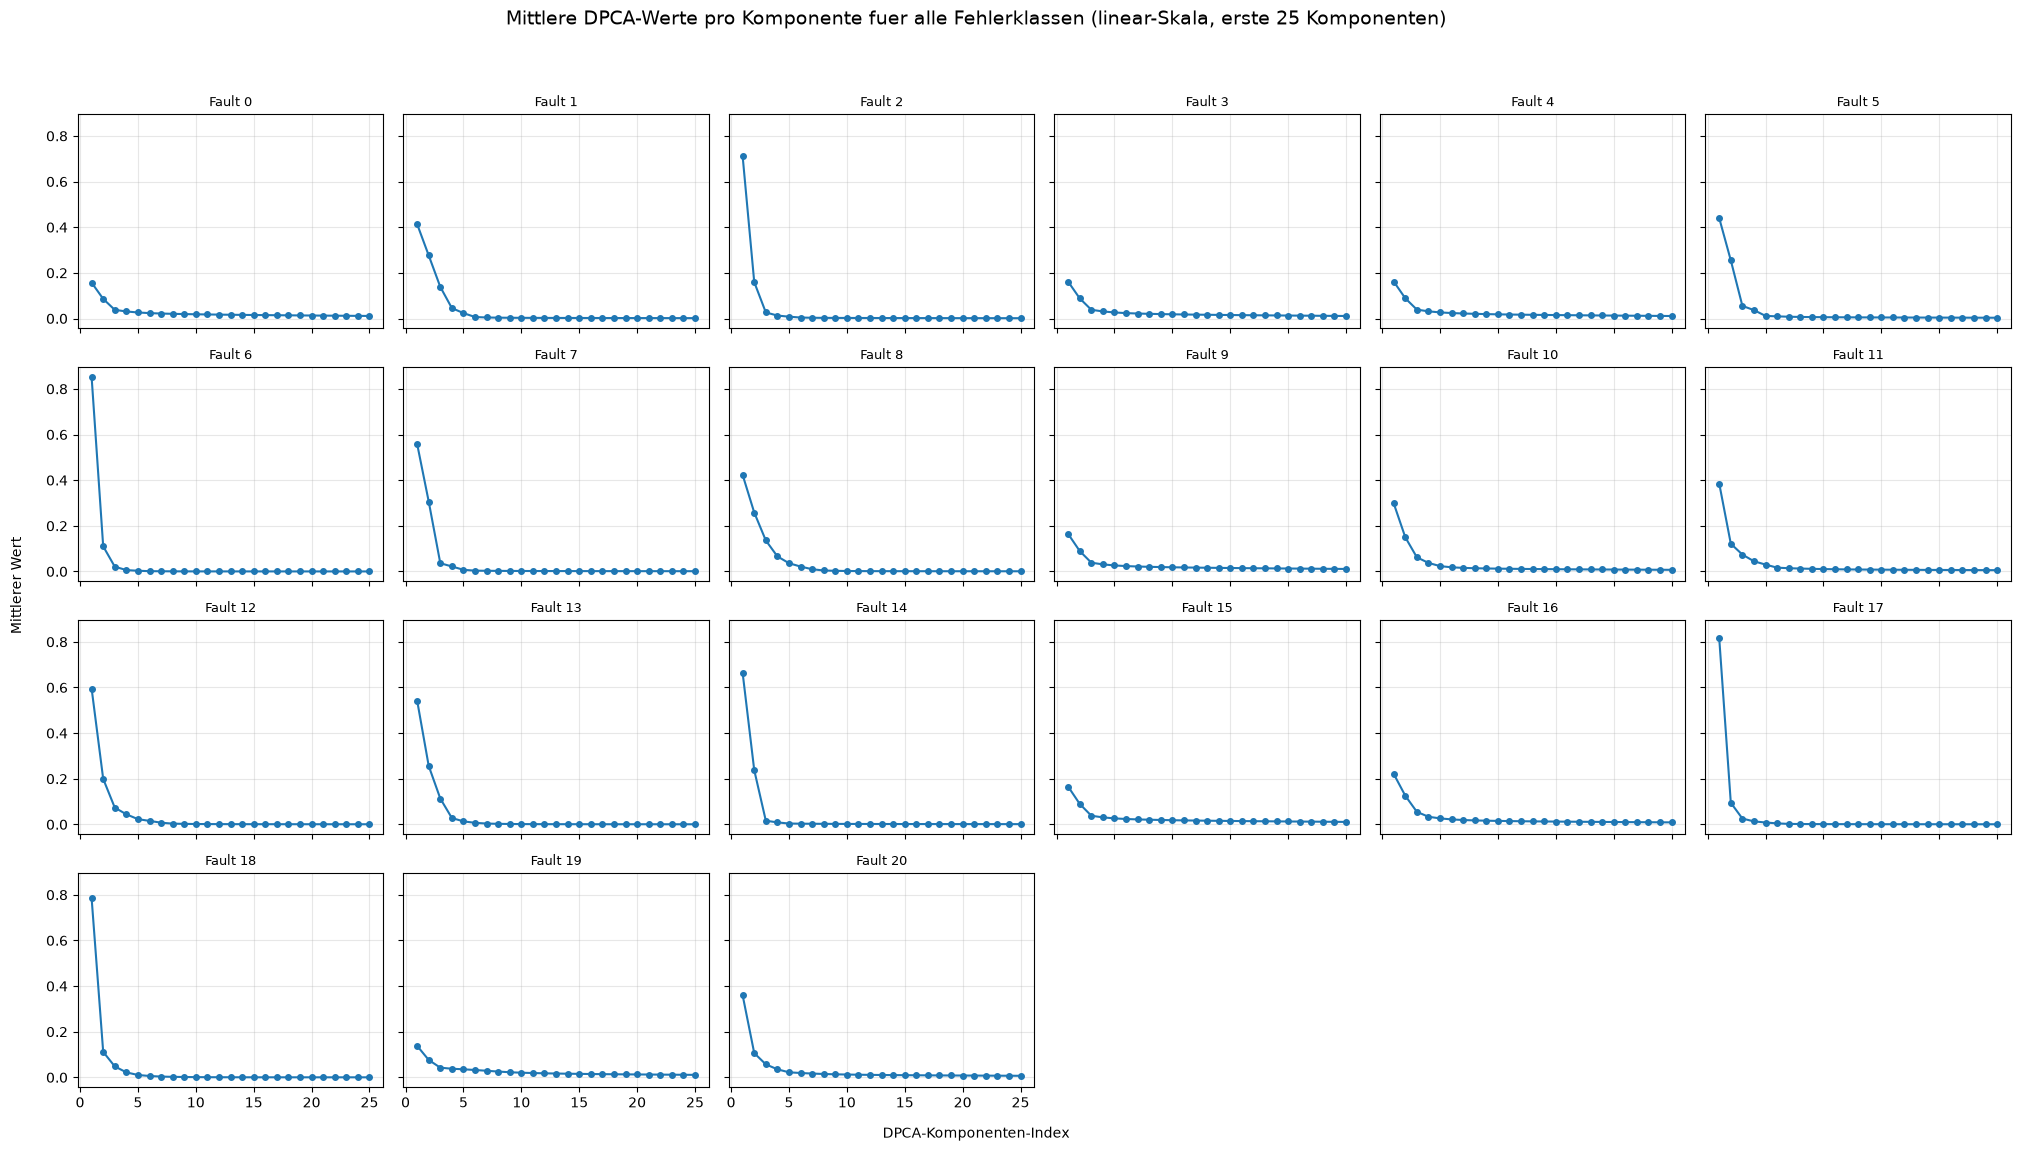

In [6]:
# ============================================================
# Mittleres Spektrum je Fehlerklasse
# ============================================================
# Ein Subplot je Fehlerklasse. Die Darstellungsart steuert
# CFG.plot_mode ("linear" | "log" | "relative"), die Zahl der
# gezeigten Komponenten CFG.k_max.
_ = plot_means(CFG, agg)

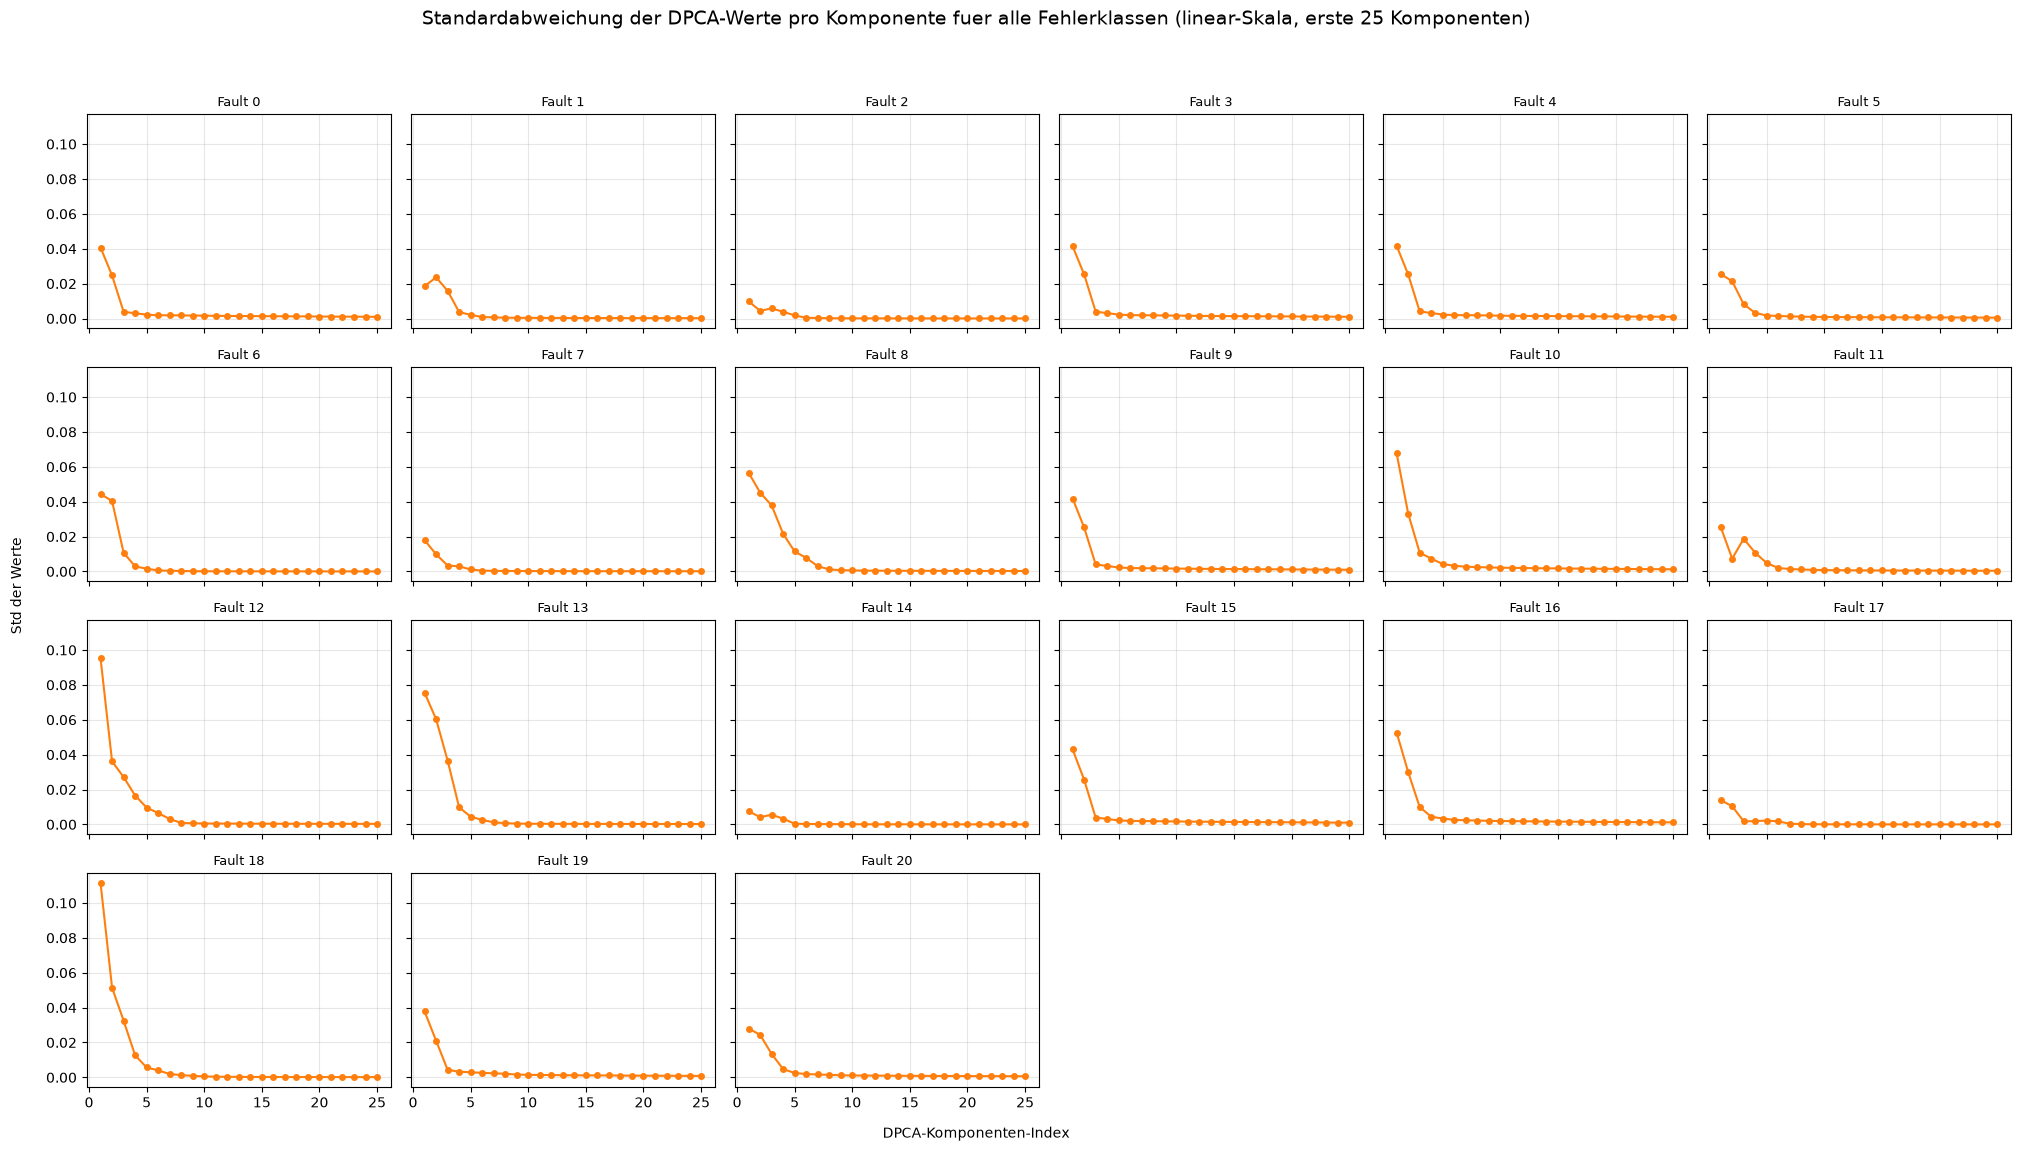

In [7]:
# ============================================================
# Standardabweichung je Komponente
# ============================================================
# Struktur identisch zum Mittelwertsplot. Eine breite Streuung heisst,
# dass die Komponente ueber die Runs einer Klasse nicht stabil ist.
_ = plot_stds(CFG, agg)

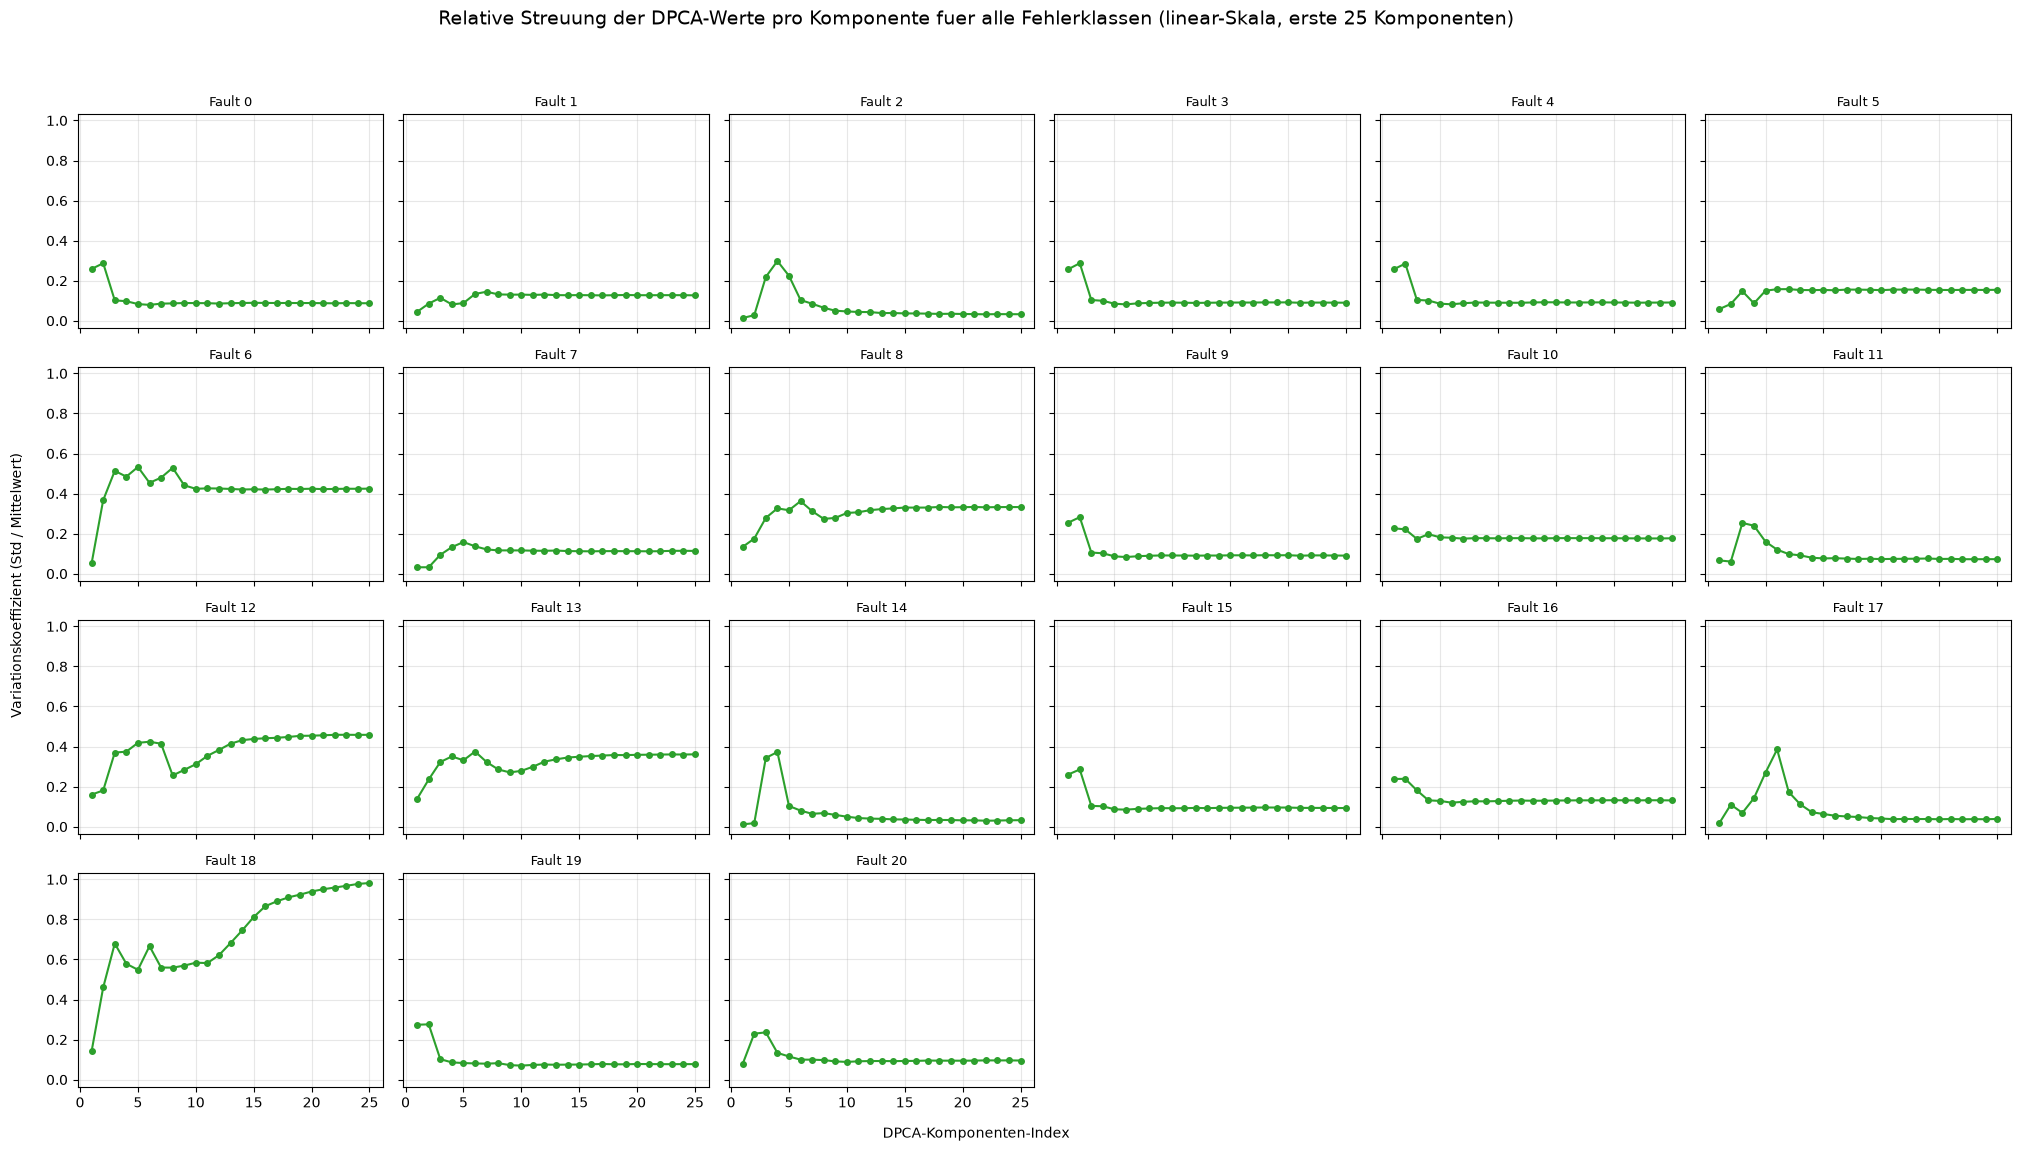

In [8]:
# ============================================================
# Relative Streuung: Variationskoeffizient CV = Std / Mittelwert
# ============================================================
# Dimensionslos und damit ueber Komponenten hinweg vergleichbar, deren
# Absolutniveau um Groessenordnungen auseinanderliegt. Eigener
# Darstellungsmodus: CFG.plot_mode_cv.
_ = plot_cv(CFG, agg)

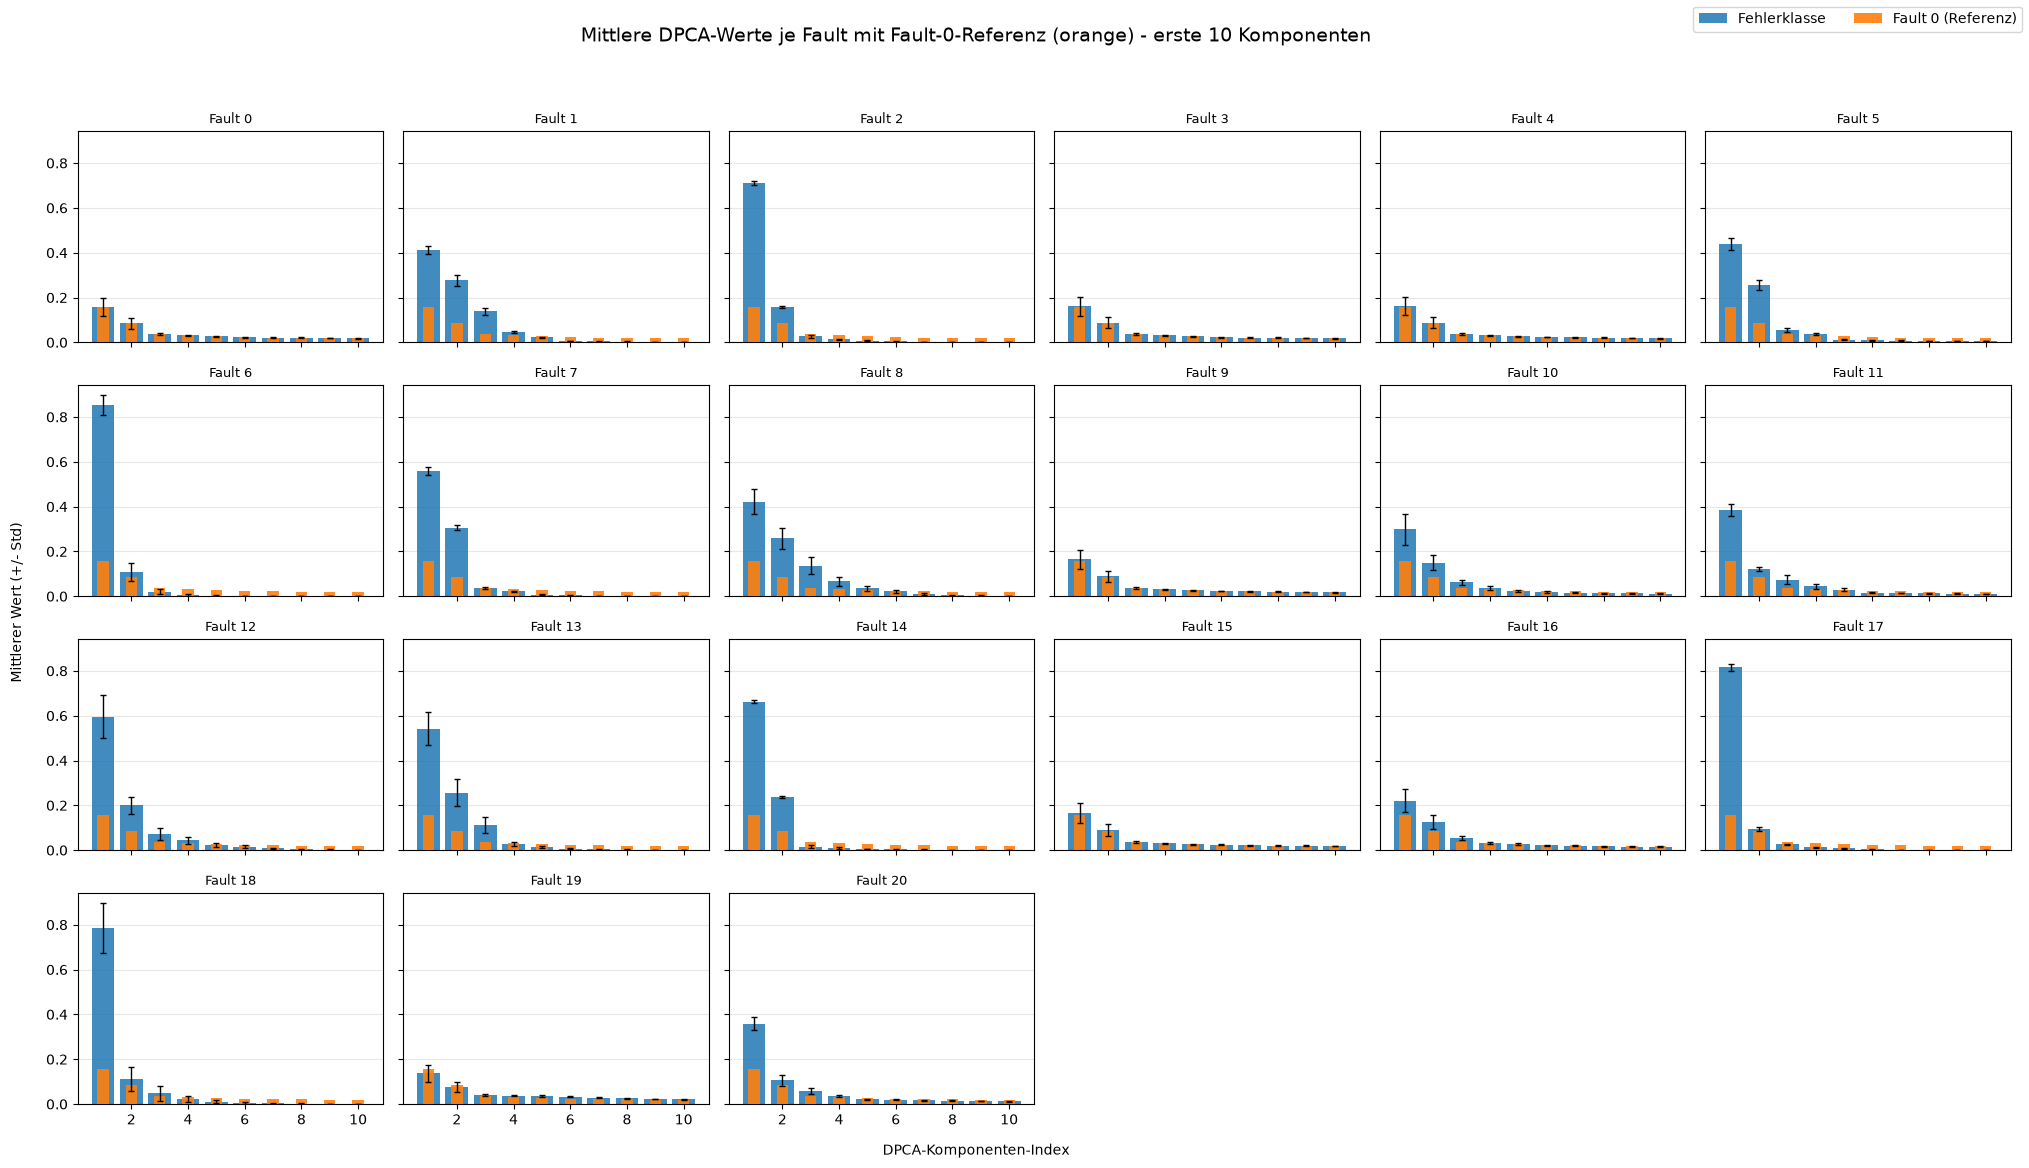

In [9]:
# ============================================================
# Erste k Werte je Fehlerklasse mit Fault-0-Referenz
# ============================================================
# Der schmale orange Balken ist Fault 0 - so ist auf einen Blick zu
# sehen, welche Komponenten sich unter dem Fehler wirklich verschieben.
# Zahl der Balken: CFG.k_bar.
_ = plot_bars(CFG, agg)

## Export der Trainings-Spektren

Schreibt `dpca_eigenvalues_train_scaler.csv` neben das Notebook. `LazyClassifier_PCA_DyCA.ipynb` liest diese Datei — der Name ist deshalb eingefroren.

In [10]:
# ============================================================
# Export der Trainings-Spektren
# ============================================================
# Stellt sie fuer LazyClassifier_PCA_DyCA.ipynb bereit. Die TEST-Spektren
# werden bewusst NICHT hier berechnet, sondern dort - dieses Notebook
# bleibt training-only. Der Dateiname enthaelt den Skalierungsmodus, ein
# Umschalten ueberschreibt also nichts.
export(CFG, per_run)

DPCA-Train gespeichert: (10500, 158) -> .\dpca_eigenvalues_train_scaler.csv


'.\\dpca_eigenvalues_train_scaler.csv'